In [291]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats.mstats import winsorize
from scipy.stats import chi2_contingency

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.svm import SVR

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

import lightgbm as lgb

In [292]:
# data load
df = pd.read_csv('Data_Polis.csv')

print("Data Polis")
display(df.head()) 

print("\ndata info")
print(df.info())

# data load 2
df2 = pd.read_csv('Data_Klaim.csv')

print("\nData Klaim")
display(df2.head())

print("\ndata info")
print(df2.info())

Data Polis


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nomor Polis            4096 non-null   object
 1   Plan Code              4096 non-null   object
 2   Gender                 4096 non-null   object
 3   Tanggal Lahir          4096 non-null   int64 
 4   Tanggal Efektif Polis  4096 non-null   int64 
 5   Domisili               4096 non-null   object
dtypes: int64(2), object(4)
memory usage: 192.1+ KB
None

Data Klaim


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient           4590 non-null   object 
 4   ICD Diagnosis                  4621 non-null   object 
 5   ICD Description                4621 non-null   object 
 6   Status Klaim                   4627 non-null   object 
 7   Tanggal Pembayaran Klaim       4590 non-null   object 
 8   Tanggal Pasien Masuk RS        4627 non-null   object 
 9   Tanggal Pasien Keluar RS       4627 non-null   object 
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS                      4620 n

In [293]:
df['Tanggal Lahir'] = pd.to_datetime(df['Tanggal Lahir'], format='%Y%m%d')
df['Tanggal Efektif Polis'] = pd.to_datetime(df['Tanggal Efektif Polis'], format='%Y%m%d')

df2['Tanggal Pembayaran Klaim'] = pd.to_datetime(df2['Tanggal Pembayaran Klaim'])
df2['Tanggal Pasien Masuk RS'] = pd.to_datetime(df2['Tanggal Pasien Masuk RS'])
df2['Tanggal Pasien Keluar RS'] = pd.to_datetime(df2['Tanggal Pasien Keluar RS'])

df.dtypes
df2.dtypes

Claim ID                                 object
Nomor Polis                              object
Reimburse/Cashless                       object
Inpatient/Outpatient                     object
ICD Diagnosis                            object
ICD Description                          object
Status Klaim                             object
Tanggal Pembayaran Klaim         datetime64[ns]
Tanggal Pasien Masuk RS          datetime64[ns]
Tanggal Pasien Keluar RS         datetime64[ns]
Nominal Klaim Yang Disetujui            float64
Nominal Biaya RS Yang Terjadi           float64
Lokasi RS                                object
dtype: object


Missing value Data Polis
Series([], dtype: int64)


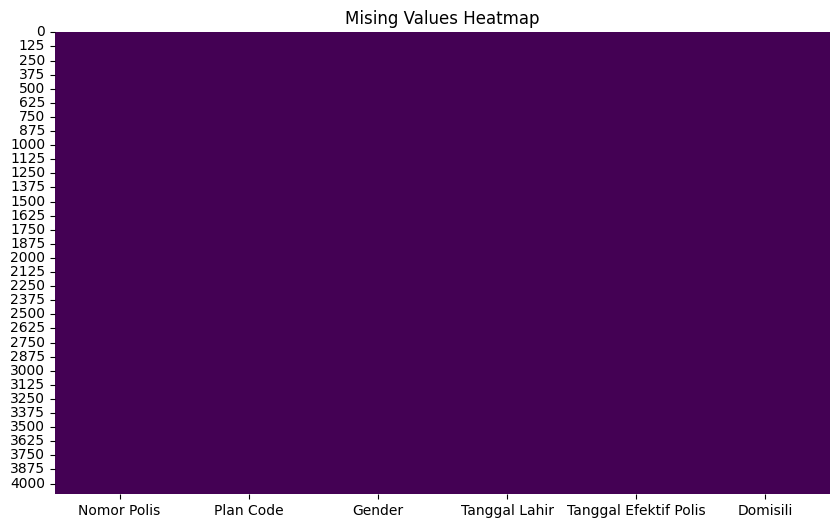


Missing value Data Klaim
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64


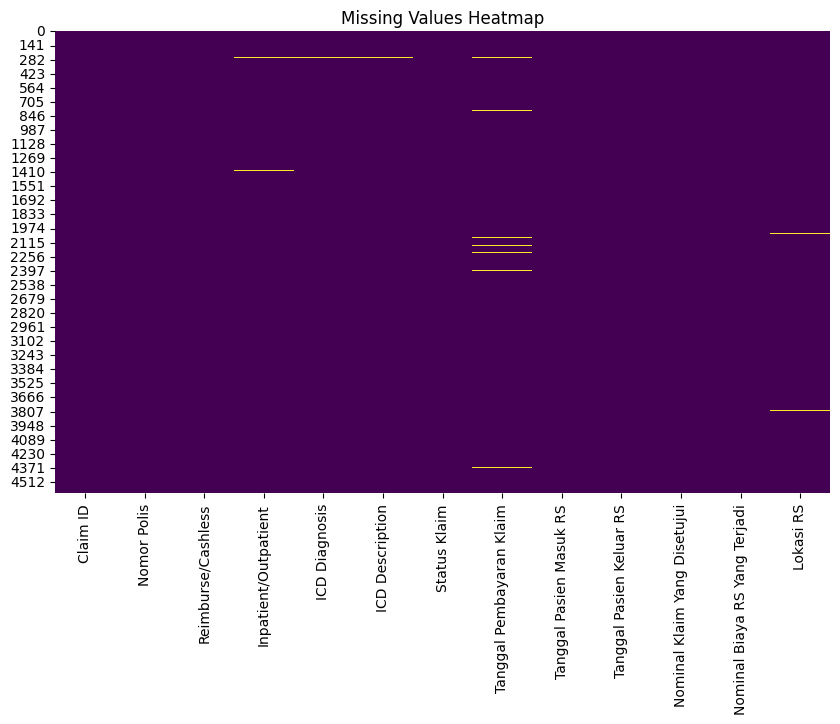

In [294]:
# missing value data polis
print("\nMissing value Data Polis")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mising Values Heatmap')
plt.show()

# missing value data klaim
print("\nMissing value Data Klaim")
missing_values = df2.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df2.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [295]:
df['Nomor Polis'] = df['Nomor Polis'].str.strip()
df2['Nomor Polis'] = df2['Nomor Polis'].str.strip()

df_final = pd.merge(df, df2, on='Nomor Polis', how='left')

print(f"Jumlah baris df_polis: {len(df)}")
print(f"Jumlah baris df_klaim: {len(df2)}")
print(f"Jumlah baris hasil merge: {len(df_final)}")

display(df_final.head())

Jumlah baris df_polis: 4096
Jumlah baris df_klaim: 4627
Jumlah baris hasil merge: 7513


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,POL-0001,M-003,M,1964-08-11,2014-06-03,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
1,POL-0002,M-003,M,1971-07-30,2014-06-03,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
2,POL-0003,M-001,M,1979-08-21,2016-08-08,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia
3,POL-0004,M-003,M,2014-07-24,2016-08-11,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
4,POL-0005,M-001,F,1981-01-14,2015-08-28,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN


In [296]:
cols_to_zero = ['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']
df_final[cols_to_zero] = df_final[cols_to_zero].fillna(0)

df_final['is_claim'] = df_final['Claim ID'].notnull().astype(int)

cat_cols = [
    'Claim ID', 'Reimburse/Cashless', 'Inpatient/Outpatient', 
    'ICD Diagnosis', 'ICD Description', 'Lokasi RS', 'Status Klaim'
]

for col in cat_cols:
    df_final.loc[df_final['is_claim'] == 0, col] = 'No Claim'
    df_final[col] = df_final[col].fillna('Unknown')

display(df_final.head())

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,is_claim
0,POL-0001,M-003,M,1964-08-11,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
1,POL-0002,M-003,M,1971-07-30,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
2,POL-0003,M-001,M,1979-08-21,2016-08-08,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia,1
3,POL-0004,M-003,M,2014-07-24,2016-08-11,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
4,POL-0005,M-001,F,1981-01-14,2015-08-28,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0


In [297]:
# Separasi Dataset
# Cluster Check untuk severity
cluster_check = df_final[df_final['Inpatient/Outpatient'].isnull() & df_final['Tanggal Pembayaran Klaim'].isnull()]
print(f"Jumlah baris dalam cluster masalah: {len(cluster_check)}")

# Dataset Severity (hanya klaim yang terjadi)
df_severity = df_final[df_final['is_claim'] == 1].copy()

# Bersihkan cluster 37 baris di data severity karena akan merusak akurasi fitur medis
df_severity = df_severity.dropna(subset=['Inpatient/Outpatient', 'ICD Diagnosis'])

# Dataset FREKUENSI 
df_frequency = df_final.copy()

print(f"Ukuran Data Severity: {df_severity.shape}")
print(f"Ukuran Data Frequency: {df_frequency.shape}")

Jumlah baris dalam cluster masalah: 0
Ukuran Data Severity: (4627, 19)
Ukuran Data Frequency: (7513, 19)


Baris sebelum drop usia negatif : 4627
Baris setelah drop usia negatif : 4627

Statistik Usia Severity:
count    4627.000000
mean       59.346490
std        12.567030
min         6.795346
25%        51.438741
50%        59.947981
75%        68.939083
max        90.324435
Name: Usia_Saat_Klaim, dtype: float64


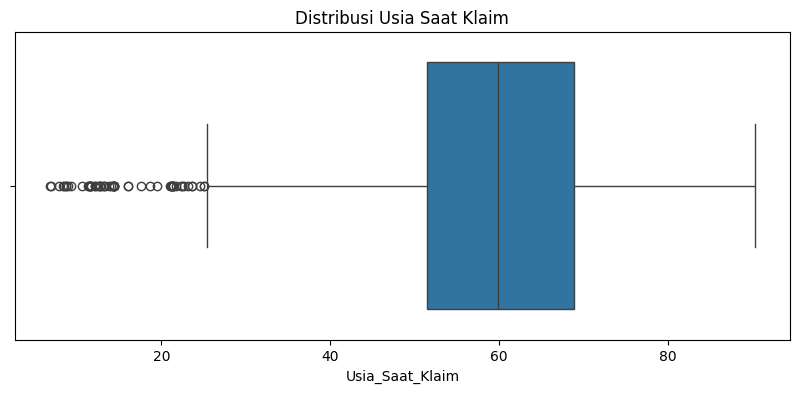

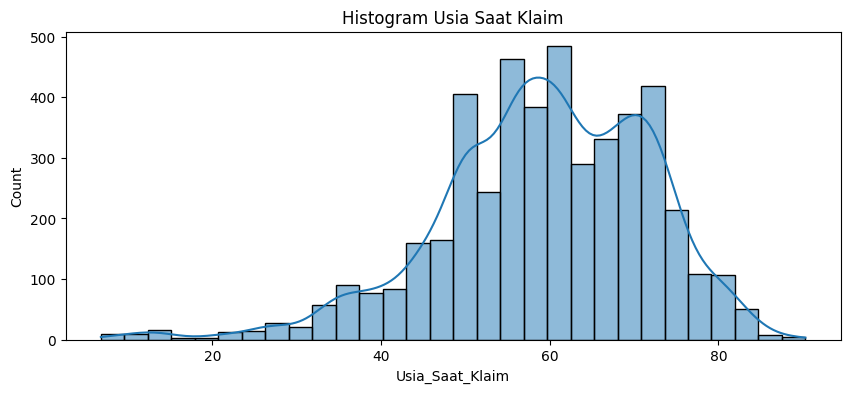

In [298]:
# Feature Engineering & Data Validation AGE)

# Hitung usia
df_severity['Usia_Saat_Klaim'] = (
    (df_severity['Tanggal Pasien Masuk RS'] - df_severity['Tanggal Lahir']).dt.days / 365.25
)

# handle usia negatif (data error)
before_rows = len(df_severity)
df_severity = df_severity[df_severity['Usia_Saat_Klaim'] >= 0].copy()
after_rows = len(df_severity)

print(f"Baris sebelum drop usia negatif : {before_rows}")
print(f"Baris setelah drop usia negatif : {after_rows}")

# Cap outlier biologis menggunakan batas logis 100 tahun
upper_cap = 100
outlier_count = (df_severity['Usia_Saat_Klaim'] > upper_cap).sum()

if outlier_count > 0:
    print(f"Ditemukan {outlier_count} usia > {upper_cap}. Akan di-cap.")
    df_severity.loc[
        df_severity['Usia_Saat_Klaim'] > upper_cap,
        'Usia_Saat_Klaim'
    ] = upper_cap

# BINNING USIA

age_bins = [0, 12, 18, 45, 65, 100]
age_labels = ['Anak', 'Remaja', 'Dewasa', 'Lansia_Awal', 'Lansia_Akhir']

df_severity['Kategori_Usia'] = pd.cut(
    df_severity['Usia_Saat_Klaim'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# USIA NASABAH (FREQUENCY)

ref_date = df_frequency['Tanggal Efektif Polis'].max()

df_frequency['Tanggal Lahir'] = pd.to_datetime(df_frequency['Tanggal Lahir'])

df_frequency['Usia_Nasabah'] = (
    (ref_date - df_frequency['Tanggal Lahir']).dt.days / 365.25
)

# Handle usia negatif 
df_frequency = df_frequency[df_frequency['Usia_Nasabah'] >= 0].copy()

# VISUALISASI
print("\nStatistik Usia Severity:")
print(df_severity['Usia_Saat_Klaim'].describe())

plt.figure(figsize=(10,4))
sns.boxplot(x=df_severity['Usia_Saat_Klaim'])
plt.title('Distribusi Usia Saat Klaim')
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df_severity['Usia_Saat_Klaim'], bins=30, kde=True)
plt.title('Histogram Usia Saat Klaim')
plt.show()

In [299]:
# Hitung Length of Stay & Bersihkan Error

# Hitung LOS
df_severity['Lama_Inap'] = (
    df_severity['Tanggal Pasien Keluar RS'] -
    df_severity['Tanggal Pasien Masuk RS']
).dt.days

# Hapus error tanggal (keluar < masuk)
before_rows = len(df_severity)
df_severity = df_severity[df_severity['Lama_Inap'] >= 0].copy()
after_rows = len(df_severity)

print(f"Baris sebelum : {before_rows}")
print(f"Baris setelah : {after_rows}")

print(df_severity['Lama_Inap'].describe())

Baris sebelum : 4627
Baris setelah : 4627
count    4627.000000
mean        1.264102
std         2.930572
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        54.000000
Name: Lama_Inap, dtype: float64


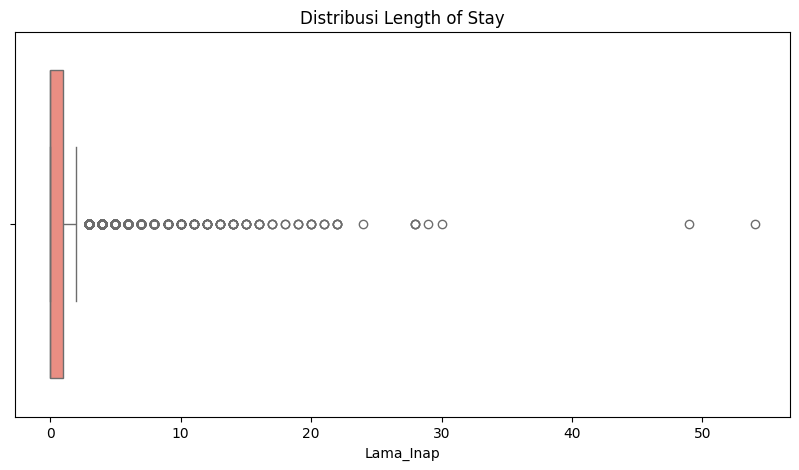

Detail LOS 54 Hari:


,Nomor Polis,ICD Description,Nominal Biaya RS Yang Terjadi,Inpatient/Outpatient
1368,POL-0830,"MALIGNANT NEOPLASM, BRONCHUS OR LUNG, UNSPECIFIED",1.465628e+09,IP


In [300]:
# Cek Outlier 54 Hari

plt.figure(figsize=(10,5))
sns.boxplot(x=df_severity['Lama_Inap'], color='salmon')
plt.title('Distribusi Length of Stay')
plt.show()

# Investigasi LOS 54 hari
outlier_54 = df_severity[df_severity['Lama_Inap'] == 54]

print("Detail LOS 54 Hari:")
display(outlier_54[['Nomor Polis',
                    'ICD Description',
                    'Nominal Biaya RS Yang Terjadi',
                    'Inpatient/Outpatient']])

In [301]:
# Feature Final LOS

# Dummy outpatient
df_severity['Is_Outpatient'] = (df_severity['Lama_Inap'] == 0).astype(int)

# Adjusted LOS (untuk hindari log(0))
df_severity['Lama_Inap_Adj'] = df_severity['Lama_Inap'] + 1

# Optional: Capping 99% (tidak akan menghapus 54 jika masih dalam batas)
los_cap = df_severity['Lama_Inap'].quantile(0.99)

df_severity['Lama_Inap_Capped'] = np.where(
    df_severity['Lama_Inap'] > los_cap,
    los_cap,
    df_severity['Lama_Inap']
)

print(f"99th percentile: {los_cap}")

print("\nStatistik Final:")
print(df_severity[['Lama_Inap','Lama_Inap_Capped']].describe())

99th percentile: 13.0

Statistik Final:
         Lama_Inap  Lama_Inap_Capped
count  4627.000000       4627.000000
mean      1.264102          1.192998
std       2.930572          2.401121
min       0.000000          0.000000
25%       0.000000          0.000000
50%       0.000000          0.000000
75%       1.000000          1.000000
max      54.000000         13.000000


In [302]:
# ==============================
# CELL 1 — MONTHLY AGGREGATION
# ==============================

# 1. ENSURE DATETIME
df_severity['Tanggal Pasien Masuk RS'] = pd.to_datetime(
    df_severity['Tanggal Pasien Masuk RS']
)

# 2. CREATE MONTH PERIOD
df_severity['Periode_Klaim'] = (
    df_severity['Tanggal Pasien Masuk RS'].dt.to_period('M')
)

# 3. AGGREGATE MONTHLY
df_monthly = df_severity.groupby('Periode_Klaim').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum'),
    Claim_Severity=('Nominal Klaim Yang Disetujui', 'mean')
).reset_index()

# 4. CONVERT TO DATETIME
df_monthly['Periode_Klaim'] = df_monthly['Periode_Klaim'].astype(str)
df_monthly['Periode_Klaim'] = pd.to_datetime(df_monthly['Periode_Klaim'])
df_monthly = df_monthly.sort_values('Periode_Klaim')

# 5. PAD MISSING MONTHS
all_months = pd.date_range(
    start=df_monthly['Periode_Klaim'].min(),
    end=df_monthly['Periode_Klaim'].max(),
    freq='MS'
)

df_monthly = (
    df_monthly
    .set_index('Periode_Klaim')
    .reindex(all_months)
    .fillna(0)
    .rename_axis('Periode_Klaim')
    .reset_index()
)

# 6. TIME INDEX
df_monthly = df_monthly.sort_values('Periode_Klaim')
df_monthly['Time_Index'] = range(len(df_monthly))

# 7. MONTH CYCLICAL FEATURE (IMPORTANT)
df_monthly['Month'] = df_monthly['Periode_Klaim'].dt.month

df_monthly['Month_sin'] = np.sin(
    2 * np.pi * df_monthly['Month'] / 12
)

df_monthly['Month_cos'] = np.cos(
    2 * np.pi * df_monthly['Month'] / 12
)

print("Cell 1 selesai.")
display(df_monthly.head())

Cell 1 selesai.


,Periode_Klaim,Claim_Frequency,Total_Claim,Claim_Severity,Time_Index,Month,Month_sin,Month_cos
0,2024-01-01,302,2.026098e+10,6.708934e+07,0,1,0.500000,8.660254e-01
1,2024-02-01,208,1.385965e+10,6.663291e+07,1,2,0.866025,5.000000e-01
2,2024-03-01,278,1.431126e+10,5.147935e+07,2,3,1.000000,6.123234e-17
3,2024-04-01,239,1.144106e+10,4.787056e+07,3,4,0.866025,-5.000000e-01
4,2024-05-01,263,1.221146e+10,4.643141e+07,4,5,0.500000,-8.660254e-01


In [303]:
# CELL REPORT: Claim Portfolio Summary 

# 1 Basic Metrics
total_claim = len(df_severity)
unique_policy_claim = df_severity['Nomor Polis'].nunique()
total_policy = df_frequency['Nomor Polis'].nunique()

avg_claim_per_policy = total_claim / unique_policy_claim

percentage_with_claim = (unique_policy_claim / total_policy) * 100
percentage_without_claim = ((total_policy - unique_policy_claim) / total_policy) * 100

# 2 DataFrame Report
df_claim_report = pd.DataFrame({
    'Total_Polis_Portfolio': [total_policy],
    'Total_Klaim': [total_claim],
    'Polis_Pernah_Klaim': [unique_policy_claim],
    'Polis_Tidak_Pernah_Klaim': [total_policy - unique_policy_claim],
    'Rata2_Klaim_per_Polis_Klaim': [round(avg_claim_per_policy, 2)],
    'Persentase_Polis_Pernah_Klaim (%)': [round(percentage_with_claim, 2)],
    'Persentase_Polis_Tidak_Klaim (%)': [round(percentage_without_claim, 2)]
})

display(df_claim_report)

,Total_Polis_Portfolio,Total_Klaim,Polis_Pernah_Klaim,Polis_Tidak_Pernah_Klaim,Rata2_Klaim_per_Polis_Klaim,Persentase_Polis_Pernah_Klaim (%),Persentase_Polis_Tidak_Klaim (%)
0,4096,4627,1210,2886,3.82,29.54,70.46


In [304]:
# ==============================
# CELL 2 — FEATURE ENGINEERING
# ==============================

df_monthly = df_monthly.sort_values('Periode_Klaim')

# -------- LAG 1–3 --------
for lag in [1, 2, 3]:
    df_monthly[f'Freq_Lag_{lag}'] = df_monthly['Claim_Frequency'].shift(lag)
    df_monthly[f'Sev_Lag_{lag}'] = df_monthly['Claim_Severity'].shift(lag)

# -------- ROLLING 6 --------
df_monthly['Freq_Rolling_6'] = (
    df_monthly['Claim_Frequency']
    .rolling(6)
    .mean()
)

df_monthly['Sev_Rolling_6'] = (
    df_monthly['Claim_Severity']
    .rolling(6)
    .mean()
)

# -------- TREND FEATURE --------
df_monthly['Freq_Trend_3'] = (
    df_monthly['Claim_Frequency']
    .diff()
    .rolling(3)
    .mean()
)

df_monthly['Sev_Trend_3'] = (
    df_monthly['Claim_Severity']
    .diff()
    .rolling(3)
    .mean()
)

# -------- CLEAN NA --------
df_monthly = df_monthly.dropna().reset_index(drop=True)

print("Cell 2 selesai.")
print("Final shape:", df_monthly.shape)
display(df_monthly.head())

Cell 2 selesai.
Final shape: (14, 18)


,Periode_Klaim,Claim_Frequency,Total_Claim,Claim_Severity,Time_Index,Month,Month_sin,Month_cos,Freq_Lag_1,Sev_Lag_1,Freq_Lag_2,Sev_Lag_2,Freq_Lag_3,Sev_Lag_3,Freq_Rolling_6,Sev_Rolling_6,Freq_Trend_3,Sev_Trend_3
0,2024-06-01,225,1.212517e+10,5.388963e+07,5,6,1.224647e-16,-1.000000e+00,263.0,4.643141e+07,239.0,4.787056e+07,278.0,5.147935e+07,252.500000,5.556553e+07,-17.666667,8.034288e+05
1,2024-07-01,257,1.497052e+10,5.825104e+07,6,7,-5.000000e-01,-8.660254e-01,225.0,5.388963e+07,263.0,4.643141e+07,239.0,4.787056e+07,245.000000,5.409248e+07,6.000000,3.460161e+06
2,2024-08-01,228,1.351294e+10,5.926726e+07,7,8,-8.660254e-01,-5.000000e-01,257.0,5.825104e+07,225.0,5.388963e+07,263.0,4.643141e+07,248.333333,5.286487e+07,-11.666667,4.278616e+06
3,2024-09-01,208,1.226412e+10,5.896211e+07,8,9,-1.000000e+00,-1.836970e-16,228.0,5.926726e+07,257.0,5.825104e+07,225.0,5.388963e+07,236.666667,5.411200e+07,-5.666667,1.690826e+06
4,2024-10-01,274,1.268117e+10,4.628163e+07,9,10,-8.660254e-01,5.000000e-01,208.0,5.896211e+07,228.0,5.926726e+07,257.0,5.825104e+07,242.500000,5.384718e+07,5.666667,-3.989804e+06


In [305]:
print (df_monthly.head())

# Cek tanggal awal dan akhir di data bulanan
print("--- Rentang Waktu Data Bulanan ---")
print("Tanggal Terawal:", df_monthly['Periode_Klaim'].min())
print("Tanggal Terbaru:", df_monthly['Periode_Klaim'].max())

# Cek jumlah bulan yang tersedia
total_bulan = len(df_monthly)
print(f"Total Observasi: {total_bulan} bulan")

  Periode_Klaim  Claim_Frequency   Total_Claim  Claim_Severity  Time_Index  \
0    2024-06-01              225  1.212517e+10    5.388963e+07           5   
1    2024-07-01              257  1.497052e+10    5.825104e+07           6   
2    2024-08-01              228  1.351294e+10    5.926726e+07           7   
3    2024-09-01              208  1.226412e+10    5.896211e+07           8   
4    2024-10-01              274  1.268117e+10    4.628163e+07           9   

   Month     Month_sin     Month_cos  Freq_Lag_1     Sev_Lag_1  Freq_Lag_2  \
0      6  1.224647e-16 -1.000000e+00       263.0  4.643141e+07       239.0   
1      7 -5.000000e-01 -8.660254e-01       225.0  5.388963e+07       263.0   
2      8 -8.660254e-01 -5.000000e-01       257.0  5.825104e+07       225.0   
3      9 -1.000000e+00 -1.836970e-16       228.0  5.926726e+07       257.0   
4     10 -8.660254e-01  5.000000e-01       208.0  5.896211e+07       228.0   

      Sev_Lag_2  Freq_Lag_3     Sev_Lag_3  Freq_Rolling_6  Sev

In [306]:
#pearson correlation matrix
numeric_cols = df_monthly.select_dtypes(include=[np.number])

# Hitung korelasi Pearson
corr_matrix = numeric_cols.corr(method='pearson')

corr_matrix

,Claim_Frequency,Total_Claim,Claim_Severity,Time_Index,Month,Month_sin,Month_cos,Freq_Lag_1,Sev_Lag_1,Freq_Lag_2,Sev_Lag_2,Freq_Lag_3,Sev_Lag_3,Freq_Rolling_6,Sev_Rolling_6,Freq_Trend_3,Sev_Trend_3
Claim_Frequency,1.000000,0.493109,-0.139102,0.016617,0.426499,-0.352115,0.133698,-0.087828,-0.193984,-0.320900,-0.150826,-0.094003,0.380537,0.132976,0.256547,0.707617,-0.333356
Total_Claim,0.493109,1.000000,0.790894,-0.012811,-0.011027,-0.013715,-0.089178,-0.163708,-0.164167,-0.331248,-0.306666,0.062035,-0.000779,0.177177,0.152518,0.272005,0.482423
Claim_Severity,-0.139102,0.790894,1.000000,-0.037957,-0.275069,0.197302,-0.201332,-0.127153,-0.016719,-0.178402,-0.218480,0.118858,-0.253658,0.108936,0.007581,-0.173508,0.775038
Time_Index,0.016617,-0.012811,-0.037957,1.000000,-0.368048,0.508376,-0.124162,-0.284954,0.163260,-0.261850,0.215336,-0.433996,0.302683,-0.748436,0.443287,0.318674,-0.220865
Month,0.426499,-0.011027,-0.275069,-0.368048,1.000000,-0.757140,0.184918,0.378183,-0.063185,-0.025361,0.072197,-0.453438,0.377752,0.226772,0.186536,0.595165,-0.414385
Month_sin,-0.352115,-0.013715,0.197302,0.508376,-0.757140,1.000000,0.053584,-0.117939,0.014770,0.000871,-0.042614,0.124457,-0.098704,-0.183391,-0.084068,-0.314002,0.184703
Month_cos,0.133698,-0.089178,-0.201332,-0.124162,0.184918,0.053584,1.000000,0.221080,-0.162354,0.235272,-0.049846,0.038567,-0.009533,0.242911,-0.616319,0.058314,-0.116450
Freq_Lag_1,-0.087828,-0.163708,-0.127153,-0.284954,0.378183,-0.117939,0.221080,1.000000,-0.200564,-0.067006,-0.306663,-0.144966,-0.146373,0.540314,-0.016307,0.046599,0.018145
Sev_Lag_1,-0.193984,-0.164167,-0.016719,0.163260,-0.063185,0.014770,-0.162354,-0.200564,1.000000,-0.129691,0.074663,-0.296145,-0.190701,-0.061555,-0.054066,0.085861,0.114394
Freq_Lag_2,-0.320900,-0.331248,-0.178402,-0.261850,-0.025361,0.000871,0.235272,-0.067006,-0.129691,1.000000,-0.191255,-0.057897,-0.313907,0.130209,-0.329545,-0.164573,0.096364


In [307]:
#frequency pearson
corr_freq = corr_matrix['Claim_Frequency'].sort_values(ascending=False)

print("Korelasi terhadap Claim_Frequency:")
print(corr_freq)

Korelasi terhadap Claim_Frequency:
Claim_Frequency    1.000000
Freq_Trend_3       0.707617
Total_Claim        0.493109
Month              0.426499
Sev_Lag_3          0.380537
Sev_Rolling_6      0.256547
Month_cos          0.133698
Freq_Rolling_6     0.132976
Time_Index         0.016617
Freq_Lag_1        -0.087828
Freq_Lag_3        -0.094003
Claim_Severity    -0.139102
Sev_Lag_2         -0.150826
Sev_Lag_1         -0.193984
Freq_Lag_2        -0.320900
Sev_Trend_3       -0.333356
Month_sin         -0.352115
Name: Claim_Frequency, dtype: float64


In [308]:
#severity pearson
corr_sev = corr_matrix['Claim_Severity'].sort_values(ascending=False)

print("Korelasi terhadap Claim_Severity:")
print(corr_sev)

Korelasi terhadap Claim_Severity:
Claim_Severity     1.000000
Total_Claim        0.790894
Sev_Trend_3        0.775038
Month_sin          0.197302
Freq_Lag_3         0.118858
Freq_Rolling_6     0.108936
Sev_Rolling_6      0.007581
Sev_Lag_1         -0.016719
Time_Index        -0.037957
Freq_Lag_1        -0.127153
Claim_Frequency   -0.139102
Freq_Trend_3      -0.173508
Freq_Lag_2        -0.178402
Month_cos         -0.201332
Sev_Lag_2         -0.218480
Sev_Lag_3         -0.253658
Month             -0.275069
Name: Claim_Severity, dtype: float64


In [309]:
# total claim pearson
corr_total = corr_matrix['Total_Claim'].sort_values(ascending=False)

print("Korelasi terhadap Total_Claim:")
print(corr_total)

Korelasi terhadap Total_Claim:
Total_Claim        1.000000
Claim_Severity     0.790894
Claim_Frequency    0.493109
Sev_Trend_3        0.482423
Freq_Trend_3       0.272005
Freq_Rolling_6     0.177177
Sev_Rolling_6      0.152518
Freq_Lag_3         0.062035
Sev_Lag_3         -0.000779
Month             -0.011027
Time_Index        -0.012811
Month_sin         -0.013715
Month_cos         -0.089178
Freq_Lag_1        -0.163708
Sev_Lag_1         -0.164167
Sev_Lag_2         -0.306666
Freq_Lag_2        -0.331248
Name: Total_Claim, dtype: float64


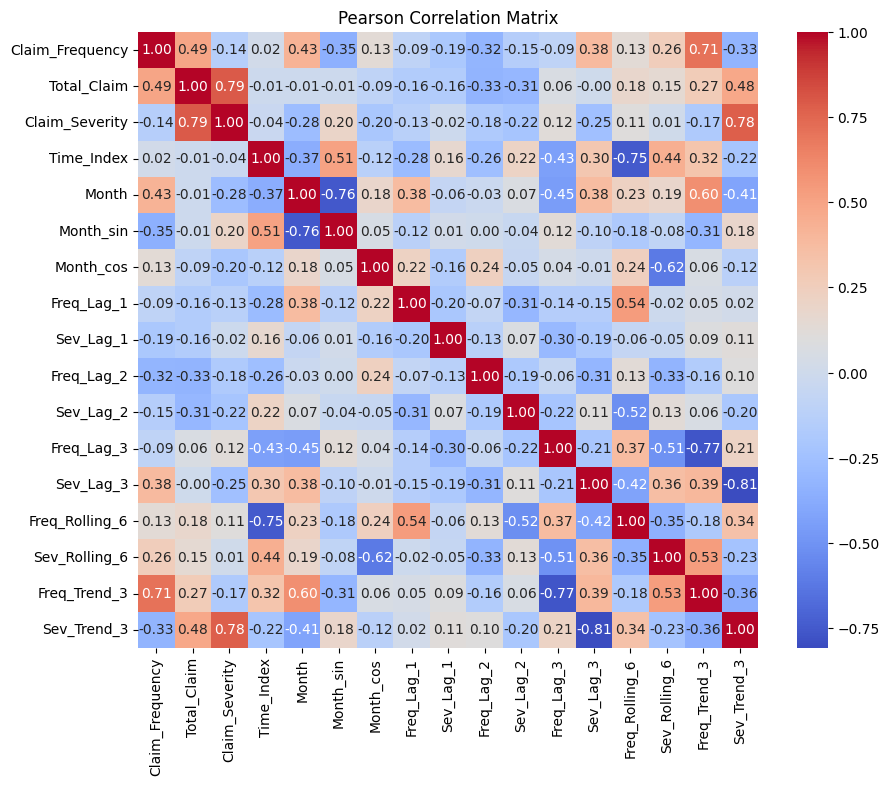

In [310]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson Correlation Matrix")
plt.show()

In [311]:
# Pastikan urut waktu
df_monthly = df_monthly.sort_values('Periode_Klaim').reset_index(drop=True)

# Train hanya sampai Juli 2025
train_df = df_monthly[df_monthly['Periode_Klaim'] <= '2025-07-01'].copy()

In [312]:
def train_best_model(df, target_col, log_transform=False):
    
    features_lean = [
        'Freq_Lag_1',
        'Sev_Lag_1',
        'Freq_Rolling_6',
        'Sev_Rolling_6',
        'Time_Index',
        'Month_sin',
        'Month_cos'
    ]
    
    # Filter fitur yang tersedia di df
    features = [f for f in features_lean if f in df.columns]
    
    X = df[features]
    y = df[target_col].copy()
    
    if log_transform:
        y = np.log1p(y)
    
    # Dengan 19 data, 3 splits lebih aman dari 4
    # Minimal ~6 bulan train di fold pertama
    tscv = TimeSeriesSplit(n_splits=3)
    
    xgb_scores = []
    svr_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # ---- XGBOOST ----
        # Regularisasi lebih ketat untuk data kecil
        xgb_model = XGBRegressor(
            n_estimators=100,
            max_depth=2,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=5,       # dinaikkan dari 2
            reg_alpha=0.1,      # tambah L1
            min_child_weight=2, # hindari split dari 1-2 sample
            random_state=42,
            verbosity=0
        )
        xgb_model.fit(X_train, y_train)
        pred_xgb = xgb_model.predict(X_val)
        
        # ---- SVR via Pipeline ----
        svr_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svr', SVR(kernel='rbf', C=10, epsilon=0.1))  # C turun dari 30
        ])
        svr_pipeline.fit(X_train, y_train)
        pred_svr = svr_pipeline.predict(X_val)
        
        # Inverse transform sebelum hitung MAPE
        if log_transform:
            y_val_orig = np.expm1(y_val)
            pred_xgb_orig = np.expm1(pred_xgb)
            pred_svr_orig = np.expm1(pred_svr)
        else:
            y_val_orig = y_val
            pred_xgb_orig = pred_xgb
            pred_svr_orig = pred_svr
        
        # MAPE lebih relevan untuk kompetisi ini
        xgb_mape = np.mean(np.abs((y_val_orig - pred_xgb_orig) / (y_val_orig + 1e-8))) * 100
        svr_mape = np.mean(np.abs((y_val_orig - pred_svr_orig) / (y_val_orig + 1e-8))) * 100
        
        xgb_scores.append(xgb_mape)
        svr_scores.append(svr_mape)
        
        print(f"Fold {fold+1}: XGB={xgb_mape:.2f}%  SVR={svr_mape:.2f}%")
    
    avg_xgb = np.mean(xgb_scores)
    avg_svr = np.mean(svr_scores)
    
    print(f"\nCV MAPE → XGB: {avg_xgb:.2f}%  |  SVR: {avg_svr:.2f}%")
    
    # ---- Retrain on full data ----
    if avg_xgb <= avg_svr:
        final_model = XGBRegressor(
            n_estimators=100,
            max_depth=2,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=5,
            reg_alpha=0.1,
            min_child_weight=2,
            random_state=42,
            verbosity=0
        )
        final_model.fit(X, y)
        
        return {
            "model": final_model,
            "scaler": None,
            "type": "xgb",
            "features": features,
            "cv_mape": avg_xgb,
            "log_transformed": log_transform
        }
    
    else:
        final_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svr', SVR(kernel='rbf', C=10, epsilon=0.1))
        ])
        final_pipeline.fit(X, y)
        
        return {
            "model": final_pipeline,
            "scaler": None,           # sudah inside pipeline
            "type": "svr",
            "features": features,
            "cv_mape": avg_svr,
            "log_transformed": log_transform
        }


def predict(result: dict, df_future: pd.DataFrame):
    """
    Helper predict yang handle log_transform & feature selection otomatis.
    Pakai ini di semua prediksi supaya konsisten.
    """
    features = result["features"]
    X = df_future[features]
    
    pred = result["model"].predict(X)
    
    if result["log_transformed"]:
        pred = np.expm1(pred)
    
    return pred

In [ ]:
# ===== Train Models =====
result_freq = train_best_model(train_df, 'Claim_Frequency', log_transform=False)
result_sev  = train_best_model(train_df, 'Claim_Severity',  log_transform=True)

print(f"Best Frequency Model : {result_freq['type'].upper()} | CV MAPE: {result_freq['cv_mape']:.2f}%")
print(f"Best Severity Model  : {result_sev['type'].upper()}  | CV MAPE: {result_sev['cv_mape']:.2f}%")

# ===== Recursive Forecast =====
def recursive_forecast(train_df, result_freq, result_sev, future_steps=5):
    
    temp_df = train_df.copy()
    
    future_records = []

    for i in range(future_steps):

        next_date = temp_df['Periode_Klaim'].max() + pd.DateOffset(months=1)
        month = next_date.month

        # Pastikan minimal 6 baris tersedia untuk rolling
        if len(temp_df) < 6:
            raise ValueError(f"Data tidak cukup untuk rolling 6 bulan di iterasi {i+1}")

        new_feat = {
            'Freq_Lag_1'    : temp_df['Claim_Frequency'].iloc[-1],
            'Sev_Lag_1'     : temp_df['Claim_Severity'].iloc[-1],
            'Freq_Rolling_6': temp_df['Claim_Frequency'].iloc[-6:].mean(),
            'Sev_Rolling_6' : temp_df['Claim_Severity'].iloc[-6:].mean(),
            'Time_Index'    : temp_df['Time_Index'].iloc[-1] + 1,
            'Month_sin'     : np.sin(2 * np.pi * month / 12),
            'Month_cos'     : np.cos(2 * np.pi * month / 12),
        }

        X_next = pd.DataFrame([new_feat])

        # ===== PREDICT — pakai helper predict() =====
        p_freq = predict(result_freq, X_next)
        p_sev  = predict(result_sev,  X_next)   # inverse log sudah di-handle predict()

        # Safety clip — tidak boleh negatif
        p_freq  = max(0.0, float(p_freq))
        p_sev   = max(0.0, float(p_sev))
        p_total = p_freq * p_sev

        future_records.append({
            'Periode_Klaim'   : next_date,
            'Claim_Frequency' : p_freq,
            'Claim_Severity'  : p_sev,
            'Total_Claim'     : p_total,
        })

        print(f"[{next_date.strftime('%b %Y')}] Freq={p_freq:.2f} | Sev={p_sev:,.0f} | Total={p_total:,.0f}")

        # Update temp_df untuk iterasi berikutnya
        new_row = pd.DataFrame([{
            'Periode_Klaim'   : next_date,
            'Claim_Frequency' : p_freq,
            'Claim_Severity'  : p_sev,
            'Total_Claim'     : p_total,
            'Time_Index'      : new_feat['Time_Index'],
        }])
        temp_df = pd.concat([temp_df, new_row], ignore_index=True)

    return pd.DataFrame(future_records)


# ===== Run =====
forecast_df = recursive_forecast(train_df, result_freq, result_sev, future_steps=5)

Fold 1: XGB=8.85%  SVR=8.23%
Fold 2: XGB=5.80%  SVR=5.94%
Fold 3: XGB=9.51%  SVR=7.88%

CV MAPE → XGB: 8.05%  |  SVR: 7.35%
Fold 1: XGB=14.34%  SVR=8.81%
Fold 2: XGB=16.18%  SVR=15.41%
Fold 3: XGB=6.59%  SVR=6.06%

CV MAPE → XGB: 12.37%  |  SVR: 10.09%
Best Frequency Model : SVR | CV MAPE: 7.35%
Best Severity Model  : SVR  | CV MAPE: 10.09%


C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_17236\1367986528.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_freq  = max(0.0, float(p_freq))
C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_17236\1367986528.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_sev   = max(0.0, float(p_sev))


[Aug 2025] Freq=237.89 | Sev=54,988,056 | Total=13,081,034,754
[Sep 2025] Freq=236.36 | Sev=54,616,935 | Total=12,909,311,774
[Oct 2025] Freq=235.66 | Sev=54,025,025 | Total=12,731,524,356
[Nov 2025] Freq=236.11 | Sev=54,358,496 | Total=12,834,805,132
[Dec 2025] Freq=235.83 | Sev=55,174,871 | Total=13,012,130,125


C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_17236\1367986528.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_freq  = max(0.0, float(p_freq))
C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_17236\1367986528.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_sev   = max(0.0, float(p_sev))
C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_17236\1367986528.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_freq  = max(0.0,

In [ ]:
def build_submission(forecast_df, sample_submission_path='sample_submission.csv', 
                     output_path='submission.csv'):
    
    submission = pd.read_csv(sample_submission_path)
    
    # Validasi sebelum isi
    print(f"Forecast months  : {forecast_df['Periode_Klaim'].dt.strftime('%b %Y').tolist()}")
    print(f"Submission rows  : {len(submission)}")
    print(f"Submission sample:\n{submission.head(3)}\n")
    
    # Map forecast ke submission
    unfilled = []
    
    for _, row in forecast_df.iterrows():
        month_str = row['Periode_Klaim'].strftime('%Y_%m')
        
        targets = {
            f"{month_str}_Claim_Frequency" : row['Claim_Frequency'],
            f"{month_str}_Claim_Severity"  : row['Claim_Severity'],
            f"{month_str}_Total_Claim"     : row['Total_Claim'],
        }
        
        for id_key, value in targets.items():
            mask = submission['id'] == id_key
            
            if mask.sum() == 0:
                unfilled.append(id_key)
            else:
                submission.loc[mask, 'value'] = value
    
    # Cek apakah ada id di submission yang masih NaN
    missing_in_sub = submission[submission['value'].isna()]
    
    if len(unfilled) > 0:
        print(f"⚠️  ID tidak ditemukan di submission ({len(unfilled)}):")
        for u in unfilled:
            print(f"   - {u}")
    
    if len(missing_in_sub) > 0:
        print(f"⚠️  Rows masih NaN di submission ({len(missing_in_sub)}):")
        print(missing_in_sub)
    
    if len(unfilled) == 0 and len(missing_in_sub) == 0:
        submission.to_csv(output_path, index=False)
        print(f"Submission siap: '{output_path}' ({len(submission)} rows)")
    else:
        # Tetap save tapi kasih warning
        submission.to_csv(output_path, index=False)
        print(f" Submission disimpan dengan peringatan, cek log di atas.")
    
    return submission


# ===== Run =====
submission = build_submission(forecast_df)

Forecast months  : ['Aug 2025', 'Sep 2025', 'Oct 2025', 'Nov 2025', 'Dec 2025']
Submission rows  : 15
Submission sample:
                        id  value
0  2025_08_Claim_Frequency      0
1   2025_08_Claim_Severity      0
2      2025_08_Total_Claim      0

✅ Submission siap: 'submission.csv' (15 rows)


C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_17236\552831608.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '237.88865611934915' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  submission.loc[mask, 'value'] = value
